#### What is a FacetGrid?
A FacetGrid is a high-level interface in Seaborn for creating a grid of subplots (or "facets") based on the levels of up to three categorical variables. It is the foundational tool that powers other figure-level functions like catplot, lmplot, and displot.

The key concept is that FacetGrid is not a plot itself. It is a layout manager. It creates the structure of the grid and then allows you to map a plotting function onto each facet.

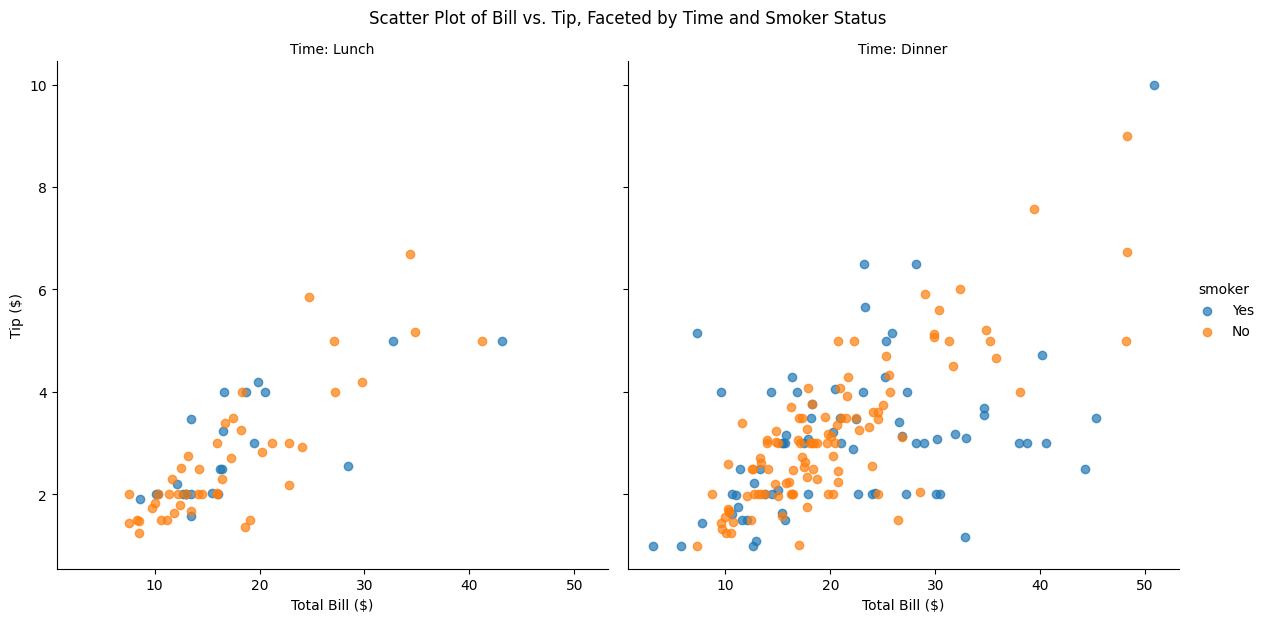

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sample Data
# Load the built-in 'tips' dataset from Seaborn
df = sns.load_dataset('tips')

# 2. Sample Code for the Plot

# --- Step 1: Initialize the FacetGrid ---
# Create the structure for the grid. At this point, the plots are empty.
# data: The DataFrame
# col: The variable to create columns with
# hue: The variable to color by
g = sns.FacetGrid(
    data=df,
    col='time', # Create columns for 'Lunch' and 'Dinner'
    hue='smoker',
    height=6 # Set the height of each facet
)

# --- Step 2: Map a plotting function onto the grid ---
# The .map() method will apply plt.scatter to the data for each facet.
# It passes the 'total_bill' and 'tip' columns to the scatter function.
g.map(plt.scatter, 'total_bill', 'tip', alpha=0.7)

# Add a legend for the 'hue' variable
g.add_legend()

# Set custom axis labels
g.set_axis_labels("Total Bill ($)", "Tip ($)")

# Set custom titles for each subplot
g.set_titles("Time: {col_name}")

# Add a main title for the entire figure
g.fig.suptitle('Scatter Plot of Bill vs. Tip, Faceted by Time and Smoker Status', y=1.03)

plt.show()

#### How Does It Work? The Two-Step Process
Using FacetGrid is a two-step process, which is what makes it different from functions like catplot.

Step 1: Initialize the Grid. You first create an instance of the FacetGrid object. In this step, you tell it what data to use and which categorical variables should be used to structure the grid using the row, col, and hue parameters. At this point, you have created a figure with a grid of empty axes.

Step 2: Map a Plotting Function. You then use the .map() method on the FacetGrid object. This method takes a plotting function (like plt.scatter or sns.histplot) and the names of the columns you want to plot. FacetGrid then automatically iterates through each subset of your data (for each facet) and applies your chosen plotting function to it.

#### What Problem Does It Solve?
FacetGrid solves the problem of needing maximum flexibility for creating faceted plots. While functions like catplot are convenient shortcuts, they are "opinionated"—they have already decided which kinds of plots you can make (e.g., kind='box').

FacetGrid is for when you want to create a faceted plot that isn't one of those standard options. It allows you to map any plotting function onto a grid, giving you complete control.

#### Advantages
Ultimate Flexibility: This is its defining feature. You can map any function that accepts data and column names. This includes standard 

Matplotlib functions (plt.scatter, plt.hist), any of Seaborn's "axes-level" functions (sns.boxplot, sns.kdeplot), or even your own custom-written plotting functions.

Full Control over Customization: It gives you direct access to the underlying grid object, allowing for fine-grained customization of titles, axis labels, and other figure properties after the plots have been drawn.

#### Disadvantages

More Verbose and Complex: It requires more lines of code and a deeper understanding of the two-step "initialize then map" process. For beginners, it's less intuitive than a one-line catplot command.

Often Unnecessary: For most common use cases (like creating a grid of boxplots or regression plots), the specialized functions (catplot, lmplot) are much faster to write and easier to read. FacetGrid is often overkill.

#### When to Use It

Rule of Thumb: Always try to use catplot, lmplot, or displot first. If you cannot create the exact visualization you want with them, then drop down to using FacetGrid directly.

Specific scenarios include:

- When you want to map a plot type not available in the specialized functions (e.g., a grid of plt.hexbin plots).\
- When you want to apply a custom function that you've written yourself to each subset of the data.
- When you need to create a more complex figure where you might map different plots to different parts of the grid (an advanced use case).

#### FacetGrid vs. catplot/lmplot/displot

| Feature | FacetGrid | catplot, lmplot, displot |
| :-- | :-- | :-- |
| Analogy | A custom car chassis and engine. You build it yourself. | A pre-built car model. You just pick the color and features. |
| Primary Use | A general-purpose framework for creating any kind of faceted plot. | Specialized shortcuts for creating common types of faceted plots. |
| Process | Two steps: 1. Initialize grid. 2. Map a plotting function. | One step: Specify the plot kind during initialization. |
| Flexibility | Maximum flexibility. Can map any plotting function. | Limited flexibility. Can only use the pre-defined kinds. |
| Ease of Use | More complex. Requires more code and understanding. | Very easy. Concise and intuitive for common tasks. |